# Phase 4 — Cross-Venue Mid Discrepancy & Executable Arb

Compares fair-value implied probability across venues, identifies crossed books, and computes realizable profit after conservative fees.

Fee assumptions (intentionally conservative; see `src/pm_micro/arb.py`):
- Polymarket: 2% taker fee, 0% maker rebate
- Kalshi: $0.02/contract execution fee

To refresh:
```bash
uv run python scripts/compute_arb.py --fresh
```

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.family"] = "monospace"

df = pd.read_csv("../data/processed/arb_results_fresh.csv")
df

,market_id,data_source,kalshi_mid,polymarket_yes_mid,polymarket_no_mid,discrepancy_direct_cents,discrepancy_synthetic_cents,crossed_direct,crossed_direct_lockable_cents,crossed_synthetic,crossed_synthetic_lockable_cents,exec_direct_fillable_size,exec_direct_net_profit,exec_direct_per_contract,exec_synthetic_fillable_size,exec_synthetic_net_profit,exec_synthetic_per_contract
0,nba_finals_okc,fresh,0.485,0.4850,0.5150,0.00,0.0,False,NaN,False,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1,nba_finals_cle,fresh,NaN,0.0045,0.9955,NaN,NaN,False,NaN,False,NaN,0.0,0.0,0.0,0.0,0.0,0.0
2,nba_finals_nyk,snapshot_fallback,0.260,0.2585,NaN,-0.15,NaN,False,NaN,False,NaN,0.0,0.0,0.0,0.0,0.0,0.0


## Headline table — paper discrepancy and executable profit

In [2]:
summary = df[[
    "market_id", "kalshi_mid", "polymarket_yes_mid",
    "discrepancy_direct_cents", "discrepancy_synthetic_cents",
    "exec_direct_fillable_size", "exec_direct_net_profit",
    "exec_synthetic_fillable_size", "exec_synthetic_net_profit",
]].copy()
summary.round(3)

,market_id,kalshi_mid,polymarket_yes_mid,discrepancy_direct_cents,discrepancy_synthetic_cents,exec_direct_fillable_size,exec_direct_net_profit,exec_synthetic_fillable_size,exec_synthetic_net_profit
0,nba_finals_okc,0.485,0.485,0.00,0.0,0.0,0.0,0.0,0.0
1,nba_finals_cle,NaN,0.004,NaN,NaN,0.0,0.0,0.0,0.0
2,nba_finals_nyk,0.260,0.258,-0.15,NaN,0.0,0.0,0.0,0.0


## Figure 1 — Paper mid-discrepancy by market

Positive = YES is more expensive on Polymarket than Kalshi (or synthetic short is cheaper than synthetic long).

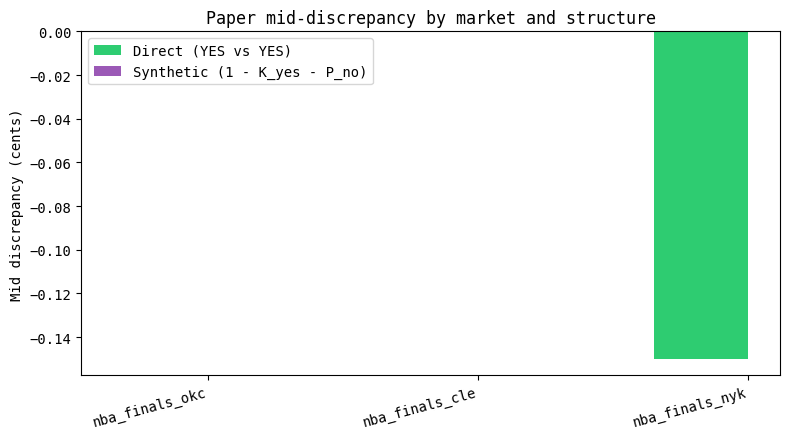

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(df))
width = 0.35
ax.bar([i - width/2 for i in x], df["discrepancy_direct_cents"], width=width, label="Direct (YES vs YES)", color="#2ecc71")
ax.bar([i + width/2 for i in x], df["discrepancy_synthetic_cents"], width=width, label="Synthetic (1 - K_yes - P_no)", color="#9b59b6")
ax.set_xticks(list(x))
ax.set_xticklabels(df["market_id"], rotation=15, ha="right")
ax.set_ylabel("Mid discrepancy (cents)")
ax.set_title("Paper mid-discrepancy by market and structure")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_mid_discrepancy.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 — Executable net profit after fees

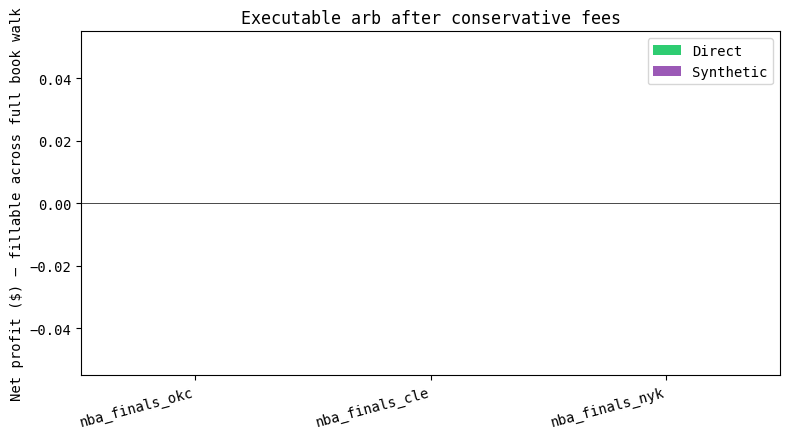

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(df))
width = 0.35
ax.bar([i - width/2 for i in x], df["exec_direct_net_profit"], width=width, label="Direct", color="#2ecc71")
ax.bar([i + width/2 for i in x], df["exec_synthetic_net_profit"], width=width, label="Synthetic", color="#9b59b6")
ax.set_xticks(list(x))
ax.set_xticklabels(df["market_id"], rotation=15, ha="right")
ax.set_ylabel("Net profit ($) — fillable across full book walk")
ax.set_title("Executable arb after conservative fees")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/fig_executable_profit.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the results

- **Paper mid-discrepancy** measures fair-value disagreement between venues — useful for identifying *which* markets disagree, but ignores execution costs.
- **Executable profit** is what a trader running cross-venue could actually capture today, after the conservative fee model. Zero means no edge survives fees.
- The gap between paper discrepancy and executable profit is *the value of a cross-venue trading terminal*: every cent of paper edge that fees eat is a cent that a more efficient venue layer could potentially preserve.